# Analysis of Tags

In [19]:
import torch
import pandas as pd

# requires the data from Zenodo
data = torch.load("data/final_se/divers_se.pt", weights_only=False)

df = pd.DataFrame.from_dict(data["info"], orient="index")
df["dvi"] = df.apply(lambda row: not (row.version in row.filename), axis=1)


## Missing Values

In [20]:
def get_nan_info(df, columns):
    n = len(df)
    for col in columns:
        if col in df.columns:
            if df[col].dtype == float or df[col].dtype == int:
                n_empty = df[col].isna().sum()
            elif df[col].dtype == object:
                n_empty = df[col].apply(len).eq(0).sum()
            print(f"{col}: {n_empty:,} missing ({n_empty / n * 100:.2f}% of total {n})")
        
columns = [
    "tempo",
    "tags_yt_title",
    "tags_yt_description",
    "tags_yt_tags",
]

print("\nNaN info for full dataset")
get_nan_info(df, columns)

print("\nNaN info for DVI dataset")
get_nan_info(df[df.dvi], columns)



NaN info for full dataset
tempo: 6 missing (0.00% of total 1102317)
tags_yt_title: 878,308 missing (79.68% of total 1102317)
tags_yt_description: 581,713 missing (52.77% of total 1102317)
tags_yt_tags: 739,379 missing (67.07% of total 1102317)

NaN info for DVI dataset
tempo: 0 missing (0.00% of total 462802)
tags_yt_title: 457,085 missing (98.76% of total 462802)
tags_yt_description: 282,825 missing (61.11% of total 462802)
tags_yt_tags: 360,282 missing (77.85% of total 462802)


## Value Distributions

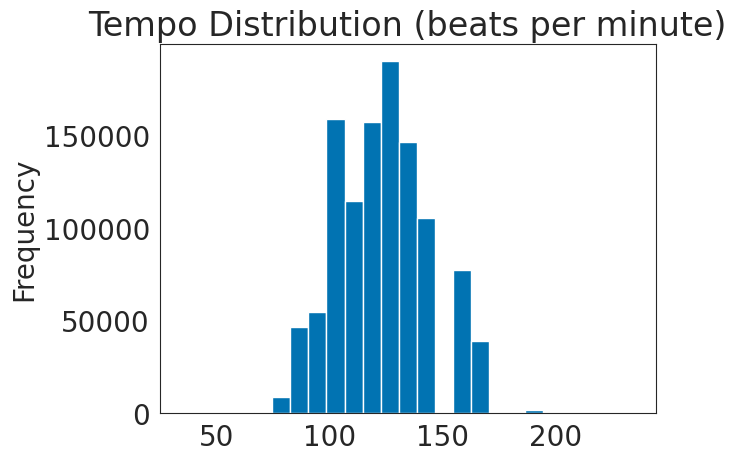

In [21]:
import matplotlib.pyplot as plt

df.tempo.plot(kind="hist", bins=25, title="Tempo Distribution (beats per minute)")
plt.show()


In [22]:
for col in ["tags_yt_title", "tags_yt_description", "tags_yt_tags"]:
    print(f"Analysis of column: {col}")
    ntags = df[col].apply(len)
    n_no_tags = (ntags == 0).sum()
    print(f"{round(n_no_tags/len(ntags)*100,2)}% of items without tags: {n_no_tags:,} out of {len(ntags):,}")
    print(ntags.describe().round(2))
    print("\n")
    

Analysis of column: tags_yt_title
79.68% of items without tags: 878,308 out of 1,102,317
count    1102317.00
mean           0.27
std            0.62
min            0.00
25%            0.00
50%            0.00
75%            0.00
max            9.00
Name: tags_yt_title, dtype: float64


Analysis of column: tags_yt_description
52.77% of items without tags: 581,713 out of 1,102,317
count    1102317.00
mean           1.44
std            2.62
min            0.00
25%            0.00
50%            0.00
75%            2.00
max           37.00
Name: tags_yt_description, dtype: float64


Analysis of column: tags_yt_tags
67.07% of items without tags: 739,379 out of 1,102,317
count    1102317.00
mean           0.82
std            1.79
min            0.00
25%            0.00
50%            0.00
75%            1.00
max           40.00
Name: tags_yt_tags, dtype: float64




/tmp/ipykernel_1522184/351038012.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(


Saved PDF: figures/matched_tags_title_overall.pdf


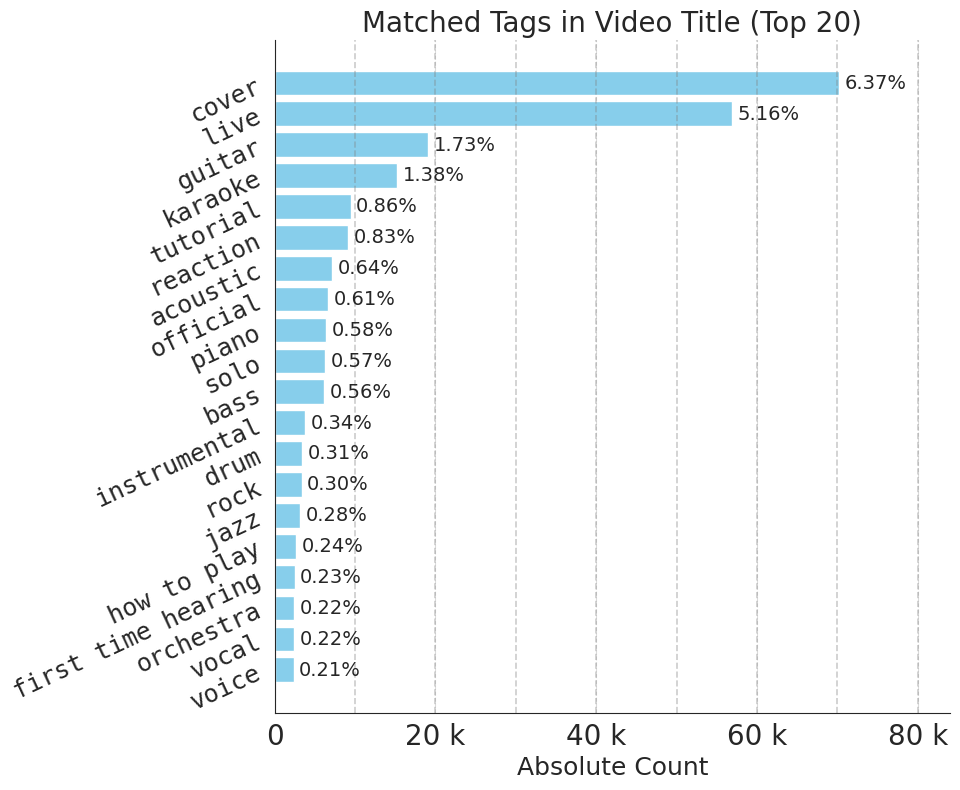

In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import seaborn as sns
import pandas as pd
import numpy as np

df["Source"] = df.apply(lambda row: "Discogs (DVI)" if row.dvi else "YouTube (YVI)", axis=1)

sns.set_palette("colorblind")
sns.set_style(style="white")


def plot_string_counts_barh(df, label_name, top_n=None, out_file=None, hue=None, stacked=False):
    """
    Horizontal bar chart for list-valued column.

    Modes:
    - hue=None → simple bar chart
    - hue given + stacked=False → grouped bars
    - hue given + stacked=True → stacked bars

    Colors are stable across runs.
    """

    # --- label formatting ---
    def format_yaxis_label(label):
        label = str(label)
        label = label.replace("firsttimehearing", "first time hearing")
        label = label.replace("howtoplay", "how to play")
        return label

    # --- explode ---
    exploded = df.explode(label_name)
    exploded[label_name] = exploded[label_name].replace({
        "firsttimehearing": "first time hearing",
        "howtoplay": "how to play"
    })

    # --- counts ---
    if hue is None:
        counts = exploded[label_name].value_counts()
        if top_n:
            counts = counts.head(top_n)
        overall_counts = counts

    else:
        exploded = exploded[[label_name, hue]].dropna()

        counts = (
            exploded.groupby([label_name, hue])
            .size()
            .unstack(fill_value=0)
        )

        if top_n:
            top_labels = counts.sum(axis=1).sort_values(ascending=False).head(top_n).index
            counts = counts.loc[top_labels]

        overall_counts = counts.sum(axis=1)

        # --- STABLE COLOR MAPPING ---
        hue_levels = sorted(counts.columns.tolist())
        palette = dict(zip(hue_levels, sns.color_palette("colorblind", n_colors=len(hue_levels))))

    # --- relative frequencies ---
    relative = overall_counts / len(df)

    # --- plot setup ---
    plt.rcParams.update({'font.size': 20})
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.grid(True, axis='x', linestyle='--', alpha=0.7)

    # --- plotting ---
    if hue is None:
        ax.barh(overall_counts.index, overall_counts.values, color='skyblue')

    else:
        plot_df = counts.reset_index().melt(
            id_vars=label_name,
            var_name=hue,
            value_name='count'
        )

        if stacked:
            # --- STACKED ---
            pivot = counts.fillna(0)
            pivot = pivot.reindex(columns=hue_levels)

            colors = [palette[c] for c in hue_levels]

            pivot.plot(
                kind="barh",
                stacked=True,
                ax=ax,
                color=colors,
                legend=True
            )

        else:
            # --- GROUPED ---
            sns.barplot(
                data=plot_df,
                y=label_name,
                x='count',
                hue=hue,
                ax=ax,
                palette=palette,
                orient='h',
                dodge=True
            )

    # --- grid lines ---
    for xtick in ax.get_xticks():
        ax.axvline(x=xtick, color='gray', linestyle='--', linewidth=1.2, alpha=0.4)

    # --- percentage labels (only single mode) ---
    if hue is None:
        max_val = overall_counts.max()
        for i, (abs_val, rel_val) in enumerate(zip(overall_counts.values, relative.values)):
            ax.text(
                abs_val + max_val * 0.01,
                i,
                f"{rel_val:.2%}",
                va='center',
                fontsize=14
            )

    # --- formatting ---
    ax.set_xlabel("Absolute Count", fontsize=18)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(EngFormatter(unit=''))
    ax.invert_yaxis()
    plt.yticks(rotation=25)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_yticklabels(
        [format_yaxis_label(t.get_text()) for t in ax.get_yticklabels()],
        fontfamily="monospace",
        fontsize=18
    )

    # --- legend (stable order) ---
    if hue is not None:
        handles, labels = ax.get_legend_handles_labels()

        if stacked:
            order = [hue_levels.index(l) for l in labels]
            sorted_idx = np.argsort(order)

            ax.legend(
                [handles[i] for i in sorted_idx],
                [labels[i] for i in sorted_idx],
                title=hue,
                loc='lower right',
                frameon=True,
                edgecolor='black',
                fontsize=16,
                title_fontsize=16
            )
        else:
            ax.legend(
                title=hue,
                loc='lower right',
                frameon=True,
                edgecolor='black',
                fontsize=16,
                title_fontsize=16
            )

    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, format='pdf', bbox_inches='tight')
        print(f"Saved PDF: {out_file}")

        # --- title ---
    title_name = label_name.split("_")[-1].title()
    ax.set_title(f"Matched Tags in Video {title_name} (Top {top_n})", fontsize=20)
    plt.show()
    
plot_string_counts_barh(df, "tags_yt_title", top_n=20, out_file="figures/matched_tags_title_overall.pdf", 
                        hue=None)

Saved PDF: figures/matched_tags_title.pdf


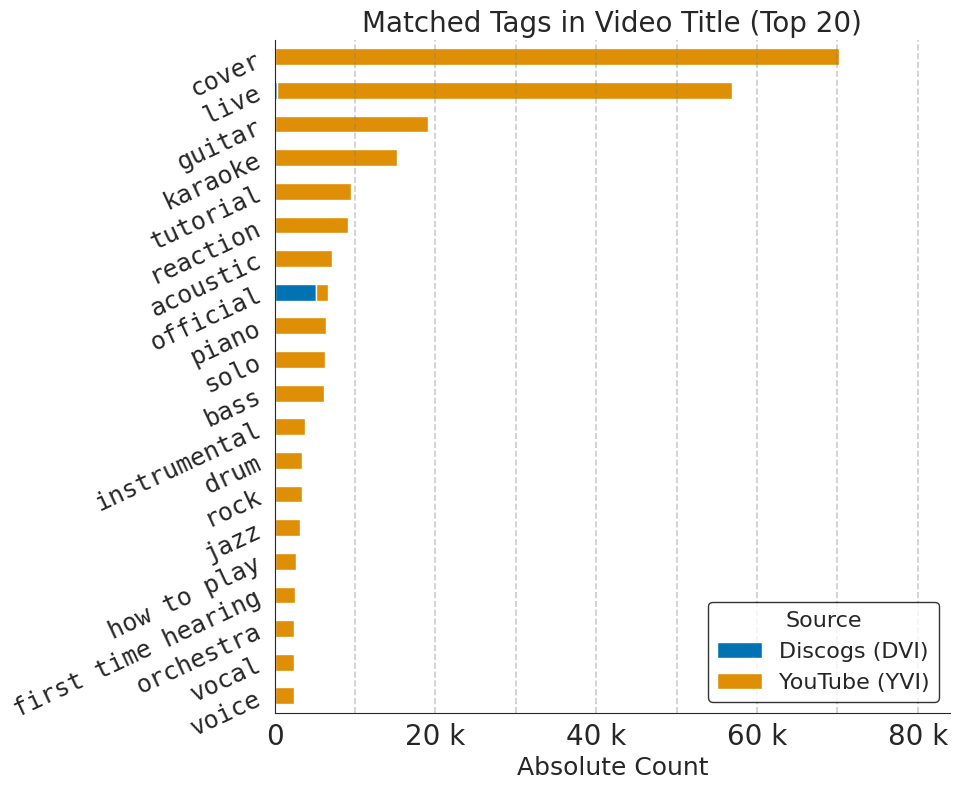

In [24]:
plot_string_counts_barh(df, "tags_yt_title", top_n=20, out_file="figures/matched_tags_title.pdf", 
                        hue="Source", stacked=True)


Saved PDF: figures/matched_tags_description.pdf


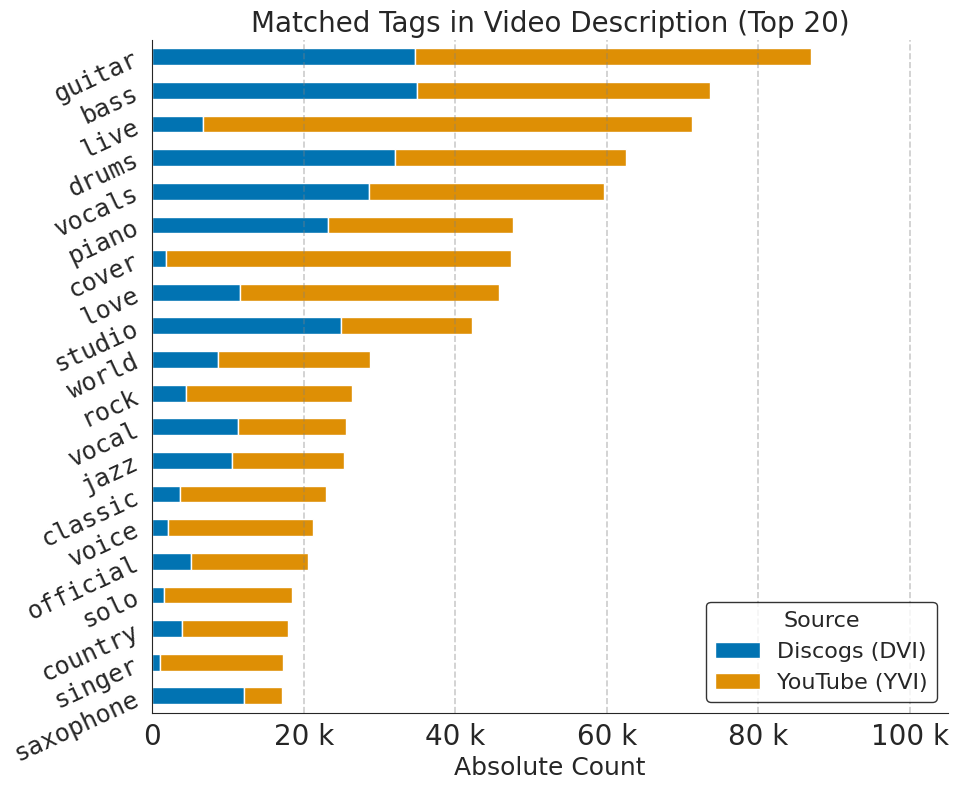

In [25]:
plot_string_counts_barh(df, "tags_yt_description", top_n=20, out_file="figures/matched_tags_description.pdf", hue="Source", 
                        stacked=True)


## Preparation for manual curation

In [7]:
# Explode lists into rows
exploded = df.explode("tags_yt_title")

# Compute tag counts and relative frequencies
n_total = len(df)
df_tag_counts = exploded["tags_yt_title"].value_counts().to_frame()
df_tag_counts["relative"] = df_tag_counts["count"] / n_total
df_tag_counts["relative"] = df_tag_counts["relative"].round(2)
df_tag_counts.sort_values("count", ascending=False).head(60)



,count,relative
tags_yt_title,,
cover,70203,0.06
live,56869,0.05
guitar,19071,0.02
karaoke,15205,0.01
tutorial,9447,0.01
reaction,9194,0.01
acoustic,7099,0.01
official,6689,0.01
piano,6352,0.01


## Annotate
To select a subset for annotation we limit to:
- $k$ most frequently occurring tags in the dataset
- our defined content types
    - backingtrack
    - cover
    - karaoke
    - reaction
    - studio
    - tutorial
    - official
- further selected tags
    - solo
    - instrumental
    - acoustic


In [ ]:
import os

# collect tags for which we curate
top_k = 15
top_k_tags = df_tag_counts.head(top_k).index.to_list()
content_type_tags = ["backingtrack", "cover", "karaoke", "reaction", "studio", "tutorial", "official"]
additional_tags = ["instrumental", "acoustic", "solo"]
curate_tags = top_k_tags + content_type_tags + additional_tags

# sample n items per tag for manual annotation
tag_cols = ["tags_yt_title", "tags_yt_description", "tags_yt_tags"]
n = 100
cols = ['id', 'clique', 'version', 'youtube_id', 'artist', 'title', 'dvi', 'yt_title', ]
for tag_col in tag_cols:
    for tag in curate_tags:
        sample = df.loc[df[tag_col].apply(lambda tags: tag in tags), cols + [tag_col, tag_col.replace("tags_", "cues_")]].sample(n=n, random_state=42)
        subdir = f"data/tags/curation/{tag_col}"
        os.makedirs(subdir, exist_ok=True)
        sample.to_csv(f"{subdir}/sample{n}_{tag}.csv", index=False)
